# Lab 15 - Test the data hypothesis with LoRA

**Goal:** test whether Dataset B improves post-opening Wordle policy when the model, LoRA setup, optimizer, schedule, and evaluation stay fixed.

Lab 13 found the data problem. Lab 14 built an intervention. This lab trains the models and accepts whatever result appears.

The causal question is:

> Does a dataset designed around deployed policy behavior outperform the original curriculum?

## 15.1 Pre-registered experiment

Dataset A is the unchanged Lab 06 corpus. Dataset B is the frozen Lab 14 corpus.

Both runs use:

- `Qwen/Qwen3-0.6B` from a fresh load;
- LoRA rank 8, alpha 16, dropout 0.05;
- `q_proj`, `k_proj`, `v_proj`, and `o_proj` targets;
- AdamW at `1e-4` with cosine decay and 5% warmup;
- batch size 16 and seed 42;
- 1,029 full-batch optimizer steps, equal to one Dataset A pass minus its final singleton row;
- the final-step adapter, with validation loss used only as a diagnostic.

Equal epochs would give Dataset A about twice the token exposure. Fixed steps substantially control optimization exposure. The notebook reports actual non-padding tokens after training.

## 15.2 Metric hierarchy

The primary metric is **fixed-state usable-policy rate** on the 47 held-out post-opening states. A successful response must be a format-valid five-letter answer-list word, avoid every guess in the supplied history, and satisfy all prior feedback. Both models receive the same states, so the denominator and difficulty mix cannot change with model behavior.

Each fixed state is evaluated twice. The training-format prompt isolates the data hypothesis and carries the primary result. The deployment-format prompt measures transfer across the known prompt mismatch.

Secondary metrics are fixed-opening solve rate, on-policy usable-call rate by turn, and candidate-set reduction by state difficulty.

Guardrails are format-valid output rate, answer-lexicon rate, repeat rate, frequent-teacher-target output, generated top-10 guess share, and auxiliary task accuracy.

This repository contains the 2,315 answer words, not Wordle's larger allowed-guess vocabulary. In this lab, `usable` therefore requires membership in the answer lexicon. That is stricter than real Wordle. Keep the name `in_answer_lexicon` so the result does not claim full legal-guess validation.

## 15.3 Run controls

The default settings execute every preflight check without starting two long MPS training runs. Set `RUN_TRAINING = True`, run through training once, then set `RUN_EVALUATION = True` after both adapter directories exist.

Existing checkpoint directories are a hard stop. Rename or remove a specific old experiment directory before starting a replacement run.

In [1]:
RUN_TRAINING = True
RUN_EVALUATION = True
EVALUATE_BASE_MODEL = True

print("RUN_TRAINING:", RUN_TRAINING)
print("RUN_EVALUATION:", RUN_EVALUATION)
print("EVALUATE_BASE_MODEL:", EVALUATE_BASE_MODEL)

RUN_TRAINING: True
RUN_EVALUATION: True
EVALUATE_BASE_MODEL: True


In [2]:
from collections import Counter
from dataclasses import dataclass
from pathlib import Path
import gc
import hashlib
import json
import math
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from datasets import load_dataset
from IPython.display import display
from peft import LoraConfig, PeftModel, TaskType, get_peft_model
from torch.optim import AdamW
from torch.utils.data import DataLoader
from transformers import AutoModelForCausalLM, AutoTokenizer

from tiny_wordle.benchmark import DEFAULT_EVAL_ANSWERS, generate_raw_guess, parse_guess
from tiny_wordle.expert import EntropyExpert
from tiny_wordle.game import Turn, filter_candidates, score_string
from tiny_wordle.hardware import preferred_device, trainable_parameter_count

MODEL_ID = "Qwen/Qwen3-0.6B"
MAX_LENGTH = 160
SEED = 42
BATCH_SIZE = 16
VAL_BATCH_SIZE = 32
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 0.01
WARMUP_FRACTION = 0.05
LOG_EVERY = 25
EVAL_EVERY = 200

DATA_DIR = Path("../data")
GENERATED_DIR = DATA_DIR / "generated"
CHECKPOINT_ROOT = Path("../checkpoints")
RESULTS_DIR = Path("../results/lab15")

CHECKPOINTS = {
    "A": CHECKPOINT_ROOT / "qwen3-0.6b-wordle-lora-dataset-a",
    "B": CHECKPOINT_ROOT / "qwen3-0.6b-wordle-lora-dataset-b",
}

device = preferred_device()
torch.set_float32_matmul_precision("high")

print("device:", device)
print("PyTorch:", torch.__version__)

device: mps
PyTorch: 2.13.0


## 15.4 Load and freeze both corpora

The Dataset A hashes must match Lab 14. Dataset B must match its manifest, keep the 19 gameplay answers out of metadata, and contain no ambiguous prompt targets.

In [3]:
DATA_FILES = {
    "A": {
        "train": GENERATED_DIR / "wordle-sft-train.jsonl",
        "validation": GENERATED_DIR / "wordle-sft-dev.jsonl",
        "test": GENERATED_DIR / "wordle-sft-test.jsonl",
    },
    "B": {
        "train": GENERATED_DIR / "wordle-part2-policy-train.jsonl",
        "validation": GENERATED_DIR / "wordle-part2-policy-dev.jsonl",
        "test": GENERATED_DIR / "wordle-part2-policy-test.jsonl",
    },
}

def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

for files in DATA_FILES.values():
    for path in files.values():
        assert path.exists(), f"Run Lab 14 first; missing {path}"

manifest_b = json.loads(
    (GENERATED_DIR / "wordle-part2-policy-manifest.json").read_text()
)

for split, expected_hash in manifest_b["control_dataset"]["sha256"].items():
    assert sha256_file(DATA_FILES["A"]["validation" if split == "dev" else split]) == expected_hash

datasets = {
    label: load_dataset("json", data_files={
        split: str(path) for split, path in files.items()
    })
    for label, files in DATA_FILES.items()
}

for manifest_split, expected_count in manifest_b["counts"].items():
    dataset_split = "validation" if manifest_split == "dev" else manifest_split
    assert datasets["B"][dataset_split].num_rows == expected_count

assert Counter(datasets["B"]["train"]["task"]) == Counter(
    manifest_b["train_task_counts"]
)
prompt_targets = {}
for split in datasets["B"]:
    for row in datasets["B"][split]:
        prompt_targets.setdefault(row["prompt"], set()).add(row["response"])
actual_ambiguous = sum(len(targets) > 1 for targets in prompt_targets.values())
assert actual_ambiguous == manifest_b["ambiguous_prompt_count"] == 0

reserved_answers = set(DEFAULT_EVAL_ANSWERS)
b_answers = {
    answer
    for split in datasets["B"]
    for answer in datasets["B"][split]["answer"]
    if answer is not None
}
assert b_answers.isdisjoint(reserved_answers)

for label, dataset in datasets.items():
    print(label, {split: dataset[split].num_rows for split in dataset})

A {'train': 16465, 'validation': 2169, 'test': 190}
B {'train': 8768, 'validation': 1135, 'test': 21}


## 15.5 Tokenize exactly as Lab 08

Only assistant response tokens contribute to the loss. Sequence-length checks run across both corpora before either model loads.

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
PAD_ID = tokenizer.pad_token_id or tokenizer.eos_token_id

def render_prompt(prompt: str) -> str:
    return tokenizer.apply_chat_template(
        [{"role": "user", "content": prompt}],
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False,
    )

def render_full_example(prompt: str, response: str) -> tuple[str, str]:
    prompt_text = render_prompt(prompt)
    return prompt_text, prompt_text + response + tokenizer.eos_token

def encode_example(example: dict) -> dict:
    prompt_text, full_text = render_full_example(
        example["prompt"], example["response"]
    )
    prompt_ids = tokenizer(prompt_text, add_special_tokens=False)["input_ids"]
    full_ids = tokenizer(full_text, add_special_tokens=False)["input_ids"]
    if len(full_ids) >= MAX_LENGTH:
        raise ValueError(
            f"sequence length {len(full_ids)} reached MAX_LENGTH={MAX_LENGTH}"
        )
    labels = [-100] * len(prompt_ids) + full_ids[len(prompt_ids):]
    assert len(labels) == len(full_ids)
    assert any(label != -100 for label in labels)
    return {"input_ids": full_ids, "labels": labels}

def collate_batch(rows: list[dict]) -> dict[str, torch.Tensor]:
    encoded = [encode_example(row) for row in rows]
    max_len = max(len(item["input_ids"]) for item in encoded)
    input_rows, label_rows, attention_rows = [], [], []
    for item in encoded:
        pad = max_len - len(item["input_ids"])
        input_rows.append(item["input_ids"] + [PAD_ID] * pad)
        label_rows.append(item["labels"] + [-100] * pad)
        attention_rows.append([1] * len(item["input_ids"]) + [0] * pad)
    return {
        "input_ids": torch.tensor(input_rows, dtype=torch.long),
        "labels": torch.tensor(label_rows, dtype=torch.long),
        "attention_mask": torch.tensor(attention_rows, dtype=torch.long),
    }

length_rows = []
for label, dataset in datasets.items():
    for split in ["train", "validation"]:
        lengths = [
            len(encode_example(row)["input_ids"])
            for row in dataset[split]
        ]
        prompt_counts = Counter(dataset[split]["prompt"])
        length_rows.append({
            "dataset": label,
            "split": split,
            "rows": len(lengths),
            "tokens": int(sum(lengths)),
            "unique_prompts": len(prompt_counts),
            "max_prompt_multiplicity": max(prompt_counts.values()),
            "mean_tokens": float(np.mean(lengths)),
            "max_tokens": max(lengths),
        })

length_df = pd.DataFrame(length_rows)
assert length_df["max_tokens"].max() < MAX_LENGTH
display(length_df)

,dataset,split,rows,tokens,unique_prompts,max_prompt_multiplicity,mean_tokens,max_tokens
0,A,train,16465,1381208,16465,1,83.887519,125
1,A,validation,2169,179358,2169,1,82.691563,125
2,B,train,8768,692075,6198,121,78.931911,125
3,B,validation,1135,89355,932,26,78.726872,124


## 15.6 Fix the optimizer-step budget

Dataset A receives one shuffled pass. Dataset B cycles through reshuffled passes until it reaches the same number of optimizer updates. The scheduler sees the same step count in both runs.

In [5]:
COMMON_STEPS = datasets["A"]["train"].num_rows // BATCH_SIZE
WARMUP_STEPS = max(1, int(COMMON_STEPS * WARMUP_FRACTION))

print("common optimizer steps:", COMMON_STEPS)
print("warmup steps:", WARMUP_STEPS)

def batch_stream(split, seed: int):
    epoch = 0
    while True:
        loader = DataLoader(
            split,
            batch_size=BATCH_SIZE,
            shuffle=True,
            drop_last=True,
            collate_fn=collate_batch,
            generator=torch.Generator().manual_seed(seed + epoch),
        )
        for batch in loader:
            yield epoch, batch
        epoch += 1

def validation_loader(split):
    return DataLoader(
        split,
        batch_size=VAL_BATCH_SIZE,
        shuffle=False,
        collate_fn=collate_batch,
    )

def planned_input_tokens(split) -> tuple[int, list[int]]:
    stream = batch_stream(split, SEED)
    total_tokens = 0
    batch_sizes = []
    for _ in range(COMMON_STEPS):
        _, batch = next(stream)
        total_tokens += int(batch["attention_mask"].sum().item())
        batch_sizes.append(batch["input_ids"].shape[0])
    return total_tokens, batch_sizes

planned_budgets = {}
for label in ["A", "B"]:
    tokens, batch_sizes = planned_input_tokens(datasets[label]["train"])
    planned_budgets[label] = {
        "input_tokens": tokens,
        "min_batch_size": min(batch_sizes),
        "max_batch_size": max(batch_sizes),
    }

planned_token_ratio = (
    planned_budgets["B"]["input_tokens"]
    / planned_budgets["A"]["input_tokens"]
)
display(pd.DataFrame(planned_budgets).T)
print("planned B/A input-token ratio:", f"{planned_token_ratio:.3f}")
assert 0.90 <= planned_token_ratio <= 1.10

common optimizer steps: 1029
warmup steps: 51


,input_tokens,min_batch_size,max_batch_size
A,1381125,16,16
B,1300155,16,16


planned B/A input-token ratio: 0.941


## 15.7 Build the same LoRA model twice

In [6]:
LORA_CONFIG = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    bias="none",
)

def reset_seeds() -> None:
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)

def build_lora_model():
    reset_seeds()
    base_model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID, dtype=torch.float32
    ).to(device)
    model = get_peft_model(base_model, LORA_CONFIG)
    trainable, total = trainable_parameter_count(model)
    print("trainable parameters:", f"{trainable:,}")
    print("total parameters:", f"{total:,}")
    print("trainable share:", f"{trainable / total:.3%}")
    return model

def release_model(model):
    model.to("cpu")
    del model
    gc.collect()
    if device.type == "mps":
        torch.mps.empty_cache()
    return None

## 15.8 Training loop

Both runs save the final adapter at step 1,029. Dataset A leaves one shuffled row out so every optimizer update contains 16 examples in both runs. Validation loss is recorded on each corpus's own dev split, so it is useful within a run but not directly comparable across datasets.

In [7]:
@torch.no_grad()
def evaluate_loss(model, loader) -> float:
    model.eval()
    weighted_loss = 0.0
    supervised_tokens = 0
    for batch in loader:
        batch = {key: value.to(device) for key, value in batch.items()}
        outputs = model(**batch)
        count = int(batch["labels"].ne(-100).sum().item())
        weighted_loss += float(outputs.loss.detach().cpu()) * count
        supervised_tokens += count
    model.train()
    return weighted_loss / supervised_tokens

def lr_multiplier(step: int) -> float:
    if step < WARMUP_STEPS:
        return (step + 1) / WARMUP_STEPS
    progress = (
        (step - WARMUP_STEPS)
        / max(1, COMMON_STEPS - WARMUP_STEPS)
    )
    return 0.5 * (1.0 + math.cos(math.pi * progress))

def train_one(label: str, dataset) -> pd.DataFrame:
    checkpoint_dir = CHECKPOINTS[label]
    in_progress_dir = checkpoint_dir.with_name(checkpoint_dir.name + "-in-progress")
    if checkpoint_dir.exists() or in_progress_dir.exists():
        raise FileExistsError(
            f"checkpoint or in-progress run already exists for {label}"
        )

    model = build_lora_model()
    optimizer = AdamW(
        (parameter for parameter in model.parameters() if parameter.requires_grad),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )
    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer, lr_lambda=lr_multiplier
    )
    train_batches = batch_stream(dataset["train"], SEED)
    val_loader = validation_loader(dataset["validation"])
    baseline_val_loss = evaluate_loss(model, val_loader)

    history = []
    processed_input_tokens = 0
    processed_supervised_tokens = 0
    start = time.perf_counter()
    model.train()

    for step in range(1, COMMON_STEPS + 1):
        epoch, batch = next(train_batches)
        batch = {key: value.to(device) for key, value in batch.items()}
        input_tokens = int(batch["attention_mask"].sum().item())
        supervised_tokens = int(batch["labels"].ne(-100).sum().item())
        processed_input_tokens += input_tokens
        processed_supervised_tokens += supervised_tokens

        optimizer.zero_grad(set_to_none=True)
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        grad_norm = torch.nn.utils.clip_grad_norm_(
            (parameter for parameter in model.parameters() if parameter.requires_grad),
            max_norm=1.0,
        )
        lr = optimizer.param_groups[0]["lr"]
        optimizer.step()
        scheduler.step()

        record = {
            "dataset": label,
            "step": step,
            "data_epoch": epoch + 1,
            "train_loss": float(loss.detach().cpu()),
            "lr": lr,
            "grad_norm": float(grad_norm),
            "input_tokens": processed_input_tokens,
            "supervised_tokens": processed_supervised_tokens,
            "val_loss": None,
        }

        if step % EVAL_EVERY == 0 or step == COMMON_STEPS:
            record["val_loss"] = evaluate_loss(model, val_loader)
            model.save_pretrained(in_progress_dir)

        history.append(record)
        if step == 1 or step % LOG_EVERY == 0:
            print(
                f"{label} step {step:4d}/{COMMON_STEPS} "
                f"loss={record['train_loss']:.4f} "
                f"lr={record['lr']:.2e} epoch={record['data_epoch']}"
            )
        if record["val_loss"] is not None:
            print(f"  {label} validation loss={record['val_loss']:.4f}")

    model.save_pretrained(in_progress_dir)
    tokenizer.save_pretrained(in_progress_dir)

    history_df = pd.DataFrame(history)
    history_df.to_csv(in_progress_dir / "training-history.csv", index=False)
    run_manifest = {
        "dataset": label,
        "base_model": MODEL_ID,
        "seed": SEED,
        "optimizer_steps": COMMON_STEPS,
        "processed_input_tokens": processed_input_tokens,
        "processed_supervised_tokens": processed_supervised_tokens,
        "baseline_val_loss": baseline_val_loss,
        "final_val_loss": next(
            row["val_loss"] for row in reversed(history) if row["val_loss"] is not None
        ),
        "elapsed_seconds": time.perf_counter() - start,
        "data_sha256": {
            split: sha256_file(path) for split, path in DATA_FILES[label].items()
        },
    }
    run_manifest["unique_train_prompts"] = len(set(dataset["train"]["prompt"]))
    run_manifest["max_prompt_multiplicity"] = max(
        Counter(dataset["train"]["prompt"]).values()
    )
    run_manifest["min_batch_size"] = planned_budgets[label]["min_batch_size"]
    (in_progress_dir / "lab15-run.json").write_text(
        json.dumps(run_manifest, indent=2)
    )
    in_progress_dir.rename(checkpoint_dir)
    model = release_model(model)
    return history_df

## 15.9 Train A and B

Run both in the same kernel session. Dataset A goes first because its one-pass step count defines the shared budget.

In [8]:
training_histories = {}

if RUN_TRAINING:
    collisions = [
        path
        for checkpoint in CHECKPOINTS.values()
        for path in [
            checkpoint,
            checkpoint.with_name(checkpoint.name + "-in-progress"),
        ]
        if path.exists()
    ]
    if collisions:
        raise FileExistsError(f"existing Lab 15 paths: {collisions}")
    for label in ["A", "B"]:
        training_histories[label] = train_one(label, datasets[label])

    run_manifests = {
        label: json.loads((path / "lab15-run.json").read_text())
        for label, path in CHECKPOINTS.items()
    }
    token_ratio = (
        run_manifests["B"]["processed_input_tokens"]
        / run_manifests["A"]["processed_input_tokens"]
    )
    print("B/A processed input token ratio:", f"{token_ratio:.3f}")
    assert 0.90 <= token_ratio <= 1.10
else:
    print("Training skipped. Set RUN_TRAINING=True to create both adapters.")

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

trainable parameters: 2,293,760
total parameters: 598,343,680
trainable share: 0.383%


A step    1/1029 loss=9.4844 lr=1.96e-06 epoch=1


A step   25/1029 loss=0.5501 lr=4.90e-05 epoch=1


A step   50/1029 loss=1.0080 lr=9.80e-05 epoch=1


...

B step  975/1029 loss=0.9499 lr=7.78e-07 epoch=2


B step 1000/1029 loss=0.8894 lr=2.32e-07 epoch=2
  B validation loss=1.8974


B step 1025/1029 loss=1.0505 lr=6.45e-09 epoch=2


  B validation loss=1.8972


B/A processed input token ratio: 0.941


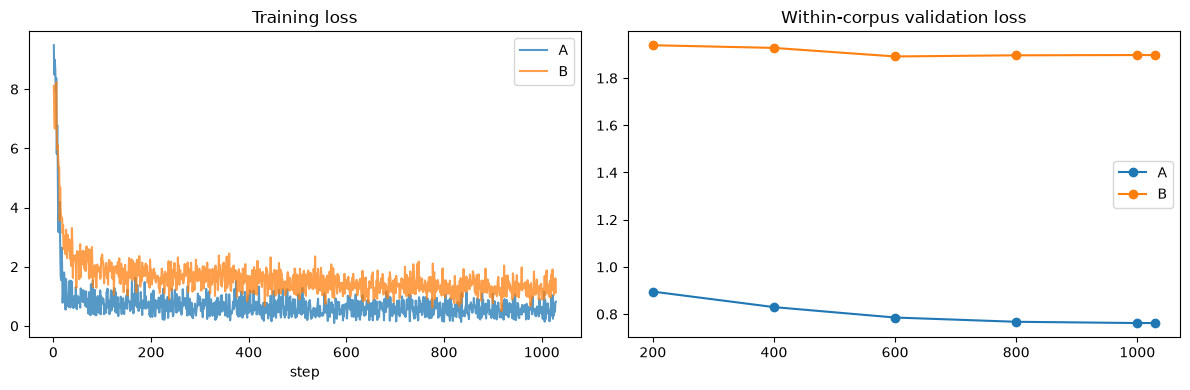

In [9]:
if training_histories:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for label, frame in training_histories.items():
        frame.plot(x="step", y="train_loss", ax=axes[0], label=label, alpha=0.75)
        val = frame.dropna(subset=["val_loss"])
        axes[1].plot(val["step"], val["val_loss"], marker="o", label=label)
    axes[0].set_title("Training loss")
    axes[1].set_title("Within-corpus validation loss")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

## 15.10 Build a common held-out policy set

The offline policy set comes from the 19 reserved answers. It excludes the no-history state and deduplicates identical model-facing histories. Lab 14 verified that neither train corpus contains these exact states.

In [10]:
ANSWERS = [
    line.strip().upper()
    for line in (DATA_DIR / "wordle-answers-original.txt").read_text().splitlines()
    if line.strip()
]
PATTERNS = np.load(DATA_DIR / "wordle-patterns-original-2315.npy")
expert = EntropyExpert(ANSWERS, PATTERNS)
WORD_TO_INDEX = expert.word_to_index
ALL_INDICES = expert.all_indices
ANSWER_SET = set(ANSWERS)

def format_training_history(history: list[Turn]) -> str:
    return "\n".join(
        f"{' '.join(turn.guess)} -> {' '.join(turn.feedback)}"
        for turn in history
    )

def next_guess_prompt(history: list[Turn]) -> str:
    return (
        "Task: NEXT_GUESS\n"
        "You are playing Wordle.\n"
        "Use the game history to choose the next guess.\n"
        "Return exactly one uppercase five-letter word.\n\n"
        "History:\n"
        f"{format_training_history(history)}"
    )

def difficulty(candidate_count: int) -> str:
    if candidate_count <= 2:
        return "1-2"
    if candidate_count <= 10:
        return "3-10"
    if candidate_count <= 50:
        return "11-50"
    if candidate_count <= 200:
        return "51-200"
    return "201+"

policy_records = {}
for answer in DEFAULT_EVAL_ANSWERS:
    history = [Turn("RAISE", score_string(answer, "RAISE"))]
    candidates = expert.update(
        ALL_INDICES, WORD_TO_INDEX["RAISE"], history[0].feedback
    )
    for turn in range(2, 7):
        state_key = format_training_history(history)
        guess_idx = expert.choose(candidates)
        guess = ANSWERS[guess_idx]
        policy_records.setdefault(state_key, {
            "state_key": state_key,
            "answer": answer,
            "turn": turn,
            "candidate_count": len(candidates),
            "difficulty": difficulty(len(candidates)),
            "history": list(history),
            "candidate_indices": tuple(int(index) for index in candidates),
            "prompt": next_guess_prompt(history),
            "response": guess,
        })
        feedback = score_string(answer, guess)
        history.append(Turn(guess, feedback))
        if feedback == "GGGGG":
            break
        candidates = expert.update(candidates, guess_idx, feedback)

policy_eval = list(policy_records.values())
print("common held-out policy states:", len(policy_eval))
display(pd.DataFrame(policy_eval)[["turn", "candidate_count", "difficulty"]].value_counts().sort_index())

common held-out policy states: 47


turn  candidate_count  difficulty
2     9                3-10          1
      10               3-10          2
      17               11-50         1
      20               11-50         1
      23               11-50         1
      26               11-50         1
      28               11-50         1
      34               11-50         1
      41               11-50         2
      51               51-200        1
      69               51-200        1
      91               51-200        1
      92               51-200        1
      107              51-200        1
      168              51-200        1
3     1                1-2           3
      2                1-2           4
      3                3-10          1
      4                3-10          3
      5                3-10          2
      6                3-10          2
      7                3-10          1
      8                3-10          2
4     1                1-2           7
      2                1-2    

## 15.11 Build a common auxiliary guardrail set

Dataset A test rows provide fixed auxiliary examples. Any prompt found in either train corpus is removed.

In [11]:
train_prompts = set(datasets["A"]["train"]["prompt"]) | set(
    datasets["B"]["train"]["prompt"]
)
assert not any(record["prompt"] in train_prompts for record in policy_eval)
aux_eval = [
    row
    for row in datasets["A"]["test"]
    if row["task"] != "NEXT_GUESS" and row["prompt"] not in train_prompts
]
assert aux_eval
print("common auxiliary rows:", len(aux_eval))
print(Counter(row["task"] for row in aux_eval))

common auxiliary rows: 147
Counter({'VALID_CANDIDATE': 98, 'CHOOSE_VALID': 49})


## 15.12 Offline policy evaluation

Exact teacher agreement is intentionally strict. Expected candidate reduction gives credit to a different legal guess when it removes a similar amount of uncertainty.

In [12]:
def normalize_exact(text: str) -> str:
    return text.strip().upper()

def expected_candidate_reduction(
    guess_index: int, candidate_indices: tuple[int, ...]
) -> float:
    patterns = PATTERNS[guess_index, np.array(candidate_indices, dtype=np.int32)]
    counts = np.bincount(patterns, minlength=243)
    expected_remaining = float(np.square(counts).sum() / len(candidate_indices))
    return len(candidate_indices) - expected_remaining

@torch.no_grad()
def generate_for_training_prompt(model, prompt: str) -> str:
    text = render_prompt(prompt)
    batch = tokenizer(text, return_tensors="pt").to(device)
    output = model.generate(
        **batch, max_new_tokens=16, do_sample=False
    )
    new_tokens = output[0, batch["input_ids"].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

def evaluate_policy_states(model, label: str, interface: str) -> pd.DataFrame:
    rows = []
    model.eval()
    for record in policy_eval:
        if interface == "training":
            raw = generate_for_training_prompt(model, record["prompt"])
        elif interface == "deployment":
            raw = generate_raw_guess(
                record["history"],
                tokenizer=tokenizer,
                model=model,
                device=device,
            )
        else:
            raise ValueError(f"unknown interface: {interface}")
        guess = parse_guess(raw)
        actual = guess or normalize_exact(raw)
        format_valid = guess is not None
        in_answer_lexicon = guess in ANSWER_SET if format_valid else False
        repeated = in_answer_lexicon and guess in {
            turn.guess for turn in record["history"]
        }
        consistent = in_answer_lexicon and all(
            score_string(guess, turn.guess) == turn.feedback
            for turn in record["history"]
        )
        usable = format_valid and in_answer_lexicon and not repeated and consistent
        teacher_reduction = expected_candidate_reduction(
            WORD_TO_INDEX[record["response"]], record["candidate_indices"]
        )
        generated_reduction = (
            expected_candidate_reduction(
                WORD_TO_INDEX[guess], record["candidate_indices"]
            )
            if in_answer_lexicon else np.nan
        )
        rows.append({
            "model": label,
            "interface": interface,
            "answer": record["answer"],
            "state_key": record["state_key"],
            "turn": record["turn"],
            "candidate_count": record["candidate_count"],
            "difficulty": record["difficulty"],
            "expected": record["response"],
            "actual": actual,
            "exact": actual == record["response"],
            "format_valid": format_valid,
            "in_answer_lexicon": in_answer_lexicon,
            "repeated": repeated,
            "history_consistent": consistent,
            "usable": usable,
            "teacher_reduction": teacher_reduction,
            "generated_reduction": generated_reduction,
            "reduction_ratio": generated_reduction / teacher_reduction
                if teacher_reduction > 0 and not np.isnan(generated_reduction)
                else np.nan,
        })
    return pd.DataFrame(rows)

def evaluate_auxiliary(model, label: str) -> pd.DataFrame:
    rows = []
    model.eval()
    for record in aux_eval:
        actual = normalize_exact(
            generate_for_training_prompt(model, record["prompt"])
        )
        rows.append({
            "model": label,
            "task": record["task"],
            "expected": record["response"].strip().upper(),
            "actual": actual,
            "correct": actual == record["response"].strip().upper(),
        })
    return pd.DataFrame(rows)

## 15.13 Fixed-opening gameplay

Every game starts with `RAISE` and its true feedback. The model receives at most five calls, covering turns 2 through 6.

In [13]:
@dataclass
class FixedOpeningGame:
    answer: str
    solved: bool
    solved_turn: int | None
    calls: list[dict]

def play_fixed_opening_game(model, answer: str) -> FixedOpeningGame:
    answer = answer.upper()
    opening_feedback = score_string(answer, "RAISE")
    history = [Turn("RAISE", opening_feedback)]
    seen = {"RAISE"}
    calls = []

    for turn_number in range(2, 7):
        candidates_before = filter_candidates(ANSWERS, history)
        raw = generate_raw_guess(
            history,
            tokenizer=tokenizer,
            model=model,
            device=device,
        )
        guess = parse_guess(raw)
        format_valid = guess is not None
        in_answer_lexicon = format_valid and guess in ANSWER_SET
        repeated = in_answer_lexicon and guess in seen
        consistent = in_answer_lexicon and all(
            score_string(guess, prior.guess) == prior.feedback
            for prior in history
        )
        usable = in_answer_lexicon and not repeated and consistent
        feedback = score_string(answer, guess) if in_answer_lexicon else None

        if in_answer_lexicon:
            seen.add(guess)
            history.append(Turn(guess, feedback))
            candidates_after = filter_candidates(ANSWERS, history)
        else:
            candidates_after = candidates_before

        calls.append({
            "answer": answer,
            "turn": turn_number,
            "raw": raw,
            "guess": guess,
            "format_valid": format_valid,
            "in_answer_lexicon": in_answer_lexicon,
            "repeated": repeated,
            "history_consistent": consistent,
            "usable": usable,
            "candidate_count_before": len(candidates_before),
            "candidate_count_after": len(candidates_after),
            "candidate_reduction": len(candidates_before) - len(candidates_after),
            "difficulty": difficulty(len(candidates_before)),
        })

        if feedback == "GGGGG":
            return FixedOpeningGame(answer, True, turn_number, calls)

    return FixedOpeningGame(answer, False, None, calls)

def evaluate_gameplay(model, label: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    games = [play_fixed_opening_game(model, answer) for answer in DEFAULT_EVAL_ANSWERS]
    call_rows = []
    game_rows = []
    for game in games:
        for call in game.calls:
            call_rows.append({"model": label, **call})
        game_rows.append({
            "model": label,
            "answer": game.answer,
            "solved": game.solved,
            "solved_turn": game.solved_turn,
            "model_calls": len(game.calls),
        })
    return pd.DataFrame(call_rows), pd.DataFrame(game_rows)

## 15.14 Evaluate both final-step adapters

In [14]:
def load_adapter(checkpoint_dir: Path):
    if not checkpoint_dir.exists():
        raise FileNotFoundError(
            f"missing adapter: {checkpoint_dir}; run training first"
        )
    base_model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID, dtype=torch.float32
    ).to(device)
    return PeftModel.from_pretrained(base_model, checkpoint_dir).to(device)

def load_evaluation_model(label: str):
    if label == "base":
        return AutoModelForCausalLM.from_pretrained(
            MODEL_ID, dtype=torch.float32
        ).to(device)
    return load_adapter(CHECKPOINTS[label])

policy_frames = []
aux_frames = []
gameplay_call_frames = []
gameplay_game_frames = []

if RUN_EVALUATION:
    evaluation_labels = (["base"] if EVALUATE_BASE_MODEL else []) + ["A", "B"]
    for label in evaluation_labels:
        model = load_evaluation_model(label)
        policy_frames.append(evaluate_policy_states(model, label, "training"))
        policy_frames.append(evaluate_policy_states(model, label, "deployment"))
        aux_frames.append(evaluate_auxiliary(model, label))
        calls, games = evaluate_gameplay(model, label)
        gameplay_call_frames.append(calls)
        gameplay_game_frames.append(games)
        model = release_model(model)

    policy_results = pd.concat(policy_frames, ignore_index=True)
    aux_results = pd.concat(aux_frames, ignore_index=True)
    gameplay_calls = pd.concat(gameplay_call_frames, ignore_index=True)
    gameplay_games = pd.concat(gameplay_game_frames, ignore_index=True)
else:
    print("Evaluation skipped. Set RUN_EVALUATION=True after both adapters exist.")

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

## 15.15 Primary result and paired uncertainty

The 47 fixed states give both models the same denominator. Bootstrap those states as paired observations.

In [15]:
def paired_bootstrap_fixed_states(
    results: pd.DataFrame,
    metric: str,
    interface: str = "training",
    samples: int = 5000,
) -> tuple[float, float, float]:
    fixed = results.loc[
        (results["interface"] == interface) & results["model"].isin(["A", "B"])
    ]
    state_keys = sorted(fixed["state_key"].unique())
    rng = np.random.default_rng(SEED)
    differences = []
    for _ in range(samples):
        sampled = rng.choice(state_keys, size=len(state_keys), replace=True)
        rates = {}
        for label in ["A", "B"]:
            values = [
                float(fixed.loc[
                    (fixed["model"] == label) & (fixed["state_key"] == state_key),
                    metric,
                ].iloc[0])
                for state_key in sampled
            ]
            rates[label] = float(np.mean(values))
        differences.append(rates["B"] - rates["A"])
    point = (
        fixed.loc[fixed["model"] == "B", metric].mean()
        - fixed.loc[fixed["model"] == "A", metric].mean()
    )
    low, high = np.quantile(differences, [0.025, 0.975])
    return float(point), float(low), float(high)

if RUN_EVALUATION:
    primary_rows = policy_results.loc[policy_results["interface"] == "training"]
    primary = primary_rows.groupby("model").agg(
        calls=("usable", "size"),
        usable_calls=("usable", "sum"),
        usable_rate=("usable", "mean"),
    )
    display(primary)
    primary_difference = paired_bootstrap_fixed_states(policy_results, "usable")
    print("B - A usable-rate difference and 95% interval:", primary_difference)

,calls,usable_calls,usable_rate
model,,,
A,47,0,0.00000
B,47,3,0.06383
base,47,0,0.00000


B - A usable-rate difference and 95% interval: (0.06382978723404255, 0.0, 0.14893617021276595)


## 15.16 Secondary metrics

In [16]:
if RUN_EVALUATION:
    solve_summary = gameplay_games.groupby("model").agg(
        games=("solved", "size"),
        solved=("solved", "sum"),
        solve_rate=("solved", "mean"),
        mean_turns_on_wins=("solved_turn", "mean"),
    )
    solve_summary["teacher_ceiling"] = 18 / 19
    display(solve_summary)
    display(gameplay_games.loc[gameplay_games["answer"] == "WASTE"])

    display(gameplay_calls.groupby(["model", "turn"]).agg(
        calls=("usable", "size"),
        usable_rate=("usable", "mean"),
    ))

    reduction_rows = gameplay_calls.loc[
        gameplay_calls["format_valid"]
        & ~gameplay_calls["repeated"]
        & gameplay_calls["history_consistent"]
    ].copy()
    reduction_rows["state_size"] = np.where(
        reduction_rows["candidate_count_before"] >= 11, "broad", "narrow"
    )
    display(reduction_rows.groupby(["model", "state_size"]).agg(
        calls=("candidate_reduction", "size"),
        mean_candidate_reduction=("candidate_reduction", "mean"),
    ))

    display(policy_results.groupby(["model", "interface", "difficulty"]).agg(
        states=("exact", "size"),
        exact_agreement=("exact", "mean"),
        answer_lexicon_rate=("in_answer_lexicon", "mean"),
        usable_rate=("usable", "mean"),
        history_consistency=("history_consistent", "mean"),
        mean_reduction_ratio=("reduction_ratio", "mean"),
    ))

,games,solved,solve_rate,mean_turns_on_wins,teacher_ceiling
model,,,,,
A,19,0,0.000000,NaN,0.947368
B,19,0,0.000000,NaN,0.947368
base,19,1,0.052632,2.0,0.947368


,model,answer,solved,solved_turn,model_calls
9,base,WASTE,False,NaN,5
28,A,WASTE,False,None,5
47,B,WASTE,False,None,5


calls  usable_rate
model turn                    
A     2        19     0.000000
      3        19     0.000000
      4        19     0.000000
      5        19     0.000000
      6        19     0.000000
B     2        19     0.000000
      3        19     0.000000
      4        19     0.000000
      5        19     0.000000
      6        19     0.000000
base  2        19     0.052632
      3        18     0.000000
      4        18     0.000000
      5        18     0.000000
      6        18     0.000000

,,calls,mean_candidate_reduction
model,state_size,,
base,broad,1,25.0


states  exact_agreement  answer_lexicon_rate  \
model interface  difficulty                                                 
A     deployment 1-2             16         0.000000             0.687500   
                 11-50            8         0.000000             1.000000   
                 3-10            17         0.000000             0.588235   
                 51-200           6         0.000000             1.000000   
      training   1-2             16         0.000000             0.625000   
                 11-50            8         0.000000             1.000000   
                 3-10            17         0.000000             0.647059   
                 51-200           6         0.000000             1.000000   
B     deployment 1-2             16         0.000000             0.625000   
                 11-50            8         0.000000             0.375000   
                 3-10            17         0.058824             0.470588   
                 51-200           6         0.000000             0.500000   
      training   1-2             16         0.125000             0.625000   
                 11-50            8         0.000000             1.000000   
                 3-10            17         0.000000             0.764706   
                 51-200           6         0.000000             1.000000   
base  deployment 1-2             16         0.000000             0.375000   
                 11-50            8         0.000000             0.875000   
                 3-10            17         0.000000             0.470588   
                 51-200           6         0.000000             1.000000   
      training   1-2             16         0.000000             0.000000   
                 11-50            8         0.000000             0.000000   
                 3-10            17         0.000000             0.000000   
                 51-200           6         0.000000             0.000000   

                             usable_rate  history_consistency  \
model interface  difficulty                                     
A     deployment 1-2            0.000000             0.000000   
                 11-50          0.000000             0.000000   
                 3-10           0.000000             0.000000   
                 51-200         0.000000             0.000000   
      training   1-2            0.000000             0.000000   
                 11-50          0.000000             0.000000   
                 3-10           0.000000             0.000000   
                 51-200         0.000000             0.000000   
B     deployment 1-2            0.000000             0.000000   
                 11-50          0.000000             0.000000   
                 3-10           0.058824             0.058824   
                 51-200         0.000000             0.000000   
      training   1-2            0.187500             0.187500   
                 11-50          0.000000             0.000000   
                 3-10           0.000000             0.000000   
                 51-200         0.000000             0.000000   
base  deployment 1-2            0.000000             0.000000   
                 11-50          0.125000             0.125000   
                 3-10           0.000000             0.000000   
                 51-200         0.000000             0.000000   
      training   1-2            0.000000             0.000000   
                 11-50          0.000000             0.000000   
                 3-10           0.000000             0.000000   
                 51-200         0.000000             0.000000   

                             mean_reduction_ratio  
model interface  difficulty                        
A     deployment 1-2                     0.250000  
                 11-50                   0.596604  
                 3-10                    0.109972  
                 51-200                  0.696972  
      training   1-2   

## 15.17 Guardrails

Dataset B restores realistic action frequency. The guardrails reveal whether the model turns that weighting into indiscriminate output.

In [17]:
teacher_target_counts = {}
for label in ["A", "B"]:
    train_frame = pd.DataFrame(datasets[label]["train"])
    teacher_target_counts[label] = train_frame.loc[
        train_frame["task"] == "NEXT_GUESS", "response"
    ].value_counts()
top_teacher_targets = {
    label: set(counts.head(10).index)
    for label, counts in teacher_target_counts.items()
}

if RUN_EVALUATION:
    guardrails = gameplay_calls.groupby("model").agg(
        calls=("turn", "size"),
        format_valid_rate=("format_valid", "mean"),
        answer_lexicon_rate=("in_answer_lexicon", "mean"),
        repeat_rate=("repeated", "mean"),
        history_consistency_rate=("history_consistent", "mean"),
    )
    display(guardrails)

    valid_guesses = gameplay_calls.dropna(subset=["guess"]).copy()
    valid_guesses["dataset_b_top_target"] = valid_guesses["guess"].isin(
        top_teacher_targets["B"]
    )
    valid_guesses["own_corpus_top_target"] = [
        guess in top_teacher_targets[model] if model in top_teacher_targets else False
        for model, guess in zip(valid_guesses["model"], valid_guesses["guess"])
    ]
    valid_guesses["reserved_answer_guess"] = valid_guesses["guess"].isin(
        reserved_answers
    )
    concentration = valid_guesses.groupby("model").agg(
        valid_guesses=("guess", "size"),
        dataset_b_top_target_share=("dataset_b_top_target", "mean"),
        own_corpus_top_target_share=("own_corpus_top_target", "mean"),
        reserved_answer_guess_share=("reserved_answer_guess", "mean"),
    )
    if "base" in concentration.index:
        concentration.loc["base", "own_corpus_top_target_share"] = np.nan
    top_10_generated = (
        valid_guesses.groupby("model")["guess"]
        .value_counts()
        .groupby(level=0)
        .head(10)
        .groupby(level=0)
        .sum()
        / valid_guesses.groupby("model").size()
    )
    concentration["generated_top_10_share"] = top_10_generated
    display(concentration)
    display(valid_guesses.groupby(["model", "guess"]).size().groupby(level=0).nlargest(15))

    display(aux_results.groupby(["model", "task"])["correct"].agg(["size", "mean"]))

,calls,format_valid_rate,answer_lexicon_rate,repeat_rate,history_consistency_rate
model,,,,,
A,95,0.905263,0.905263,0.705263,0.000000
B,95,1.000000,0.200000,0.115789,0.000000
base,91,1.000000,0.186813,0.000000,0.010989


,valid_guesses,dataset_b_top_target_share,own_corpus_top_target_share,reserved_answer_guess_share,generated_top_10_share
model,,,,,
A,86,0.0,0.0,0.000000,1.0
B,95,0.2,0.2,0.000000,1.0
base,91,0.0,NaN,0.186813,1.0


model  model  guess
A      A      BRAIN    76
              BAYOU    10
B      B      BRISE    35
              PETEL    21
              RASHY    20
              BETEL    19
base   base   CRAKE    74
              CRANE    17
dtype: int64

size      mean
model task                           
A     CHOOSE_VALID       49  0.836735
      VALID_CANDIDATE    98  0.744898
B     CHOOSE_VALID       49  0.653061
      VALID_CANDIDATE    98  0.765306
base  CHOOSE_VALID       49  0.000000
      VALID_CANDIDATE    98  0.000000

## 15.18 Interpret the result without moving the goalposts

| Result | Interpretation | Next experiment |
| --- | --- | --- |
| Primary rate and broad-state policy improve | Combined data hypothesis supported | Later ablate weighting and alternative states |
| Offline policy improves, primary rate does not | Deployment representation or sequential consistency still limits play | Lab 16 failure analysis, then Lab 17 |
| Frequent-target collapse appears | Canonical visit weights are too concentrated | Cap visit weights without changing unique states |
| Neither policy nor gameplay improves | Distribution may not dominate, or repeated exposure may offset broader coverage | Inspect fit, prompt transfer, and visit weighting before generating more data |

Solve rate is important, but 19 games do not overrule the fixed-state primary metric by themselves.

## 15.19 Save the result

Persist raw records. Lab 16 needs failed calls and game traces, not only summary percentages.

In [18]:
if RUN_EVALUATION:
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    policy_results.to_csv(RESULTS_DIR / "policy-results.csv", index=False)
    aux_results.to_csv(RESULTS_DIR / "auxiliary-results.csv", index=False)
    gameplay_calls.to_csv(RESULTS_DIR / "gameplay-calls.csv", index=False)
    gameplay_games.to_csv(RESULTS_DIR / "gameplay-games.csv", index=False)

    final_summary = {
        "primary": primary.reset_index().to_dict(orient="records"),
        "primary_b_minus_a": {
            "point": primary_difference[0],
            "ci_95_low": primary_difference[1],
            "ci_95_high": primary_difference[2],
        },
        "solve": solve_summary.reset_index().to_dict(orient="records"),
        "teacher_solve_ceiling": 18 / 19,
        "waste": gameplay_games.loc[
            gameplay_games["answer"] == "WASTE"
        ].to_dict(orient="records"),
        "policy_by_interface": policy_results.groupby(
            ["model", "interface"]
        )["usable"].mean().reset_index().to_dict(orient="records"),
        "common_optimizer_steps": COMMON_STEPS,
        "fixed_opening": "RAISE",
    }
    (RESULTS_DIR / "summary.json").write_text(
        json.dumps(final_summary, indent=2)
    )
    print("saved Lab 15 results to", RESULTS_DIR)

saved Lab 15 results to ../results/lab15


# Lab 15 checkpoint

Record:

1. both run manifests and actual processed-token ratio;
2. fixed-state primary rate for A and B with the paired 95% interval;
3. fixed-opening solve rate;
4. training-format versus deployment-format policy transfer;
5. on-policy usable-call rate by turn;
6. candidate reduction on broad and narrow states;
7. frequent-target and generated top-10 shares;
8. auxiliary guardrail accuracy;
9. the pre-registered interpretation that matches the result.

Do not redesign Dataset B inside this notebook. A failed hypothesis is a result.